# Human Activity Recognition with Hidden Markov Models
**Formative 2 — Machine Learning Techniques II**

Individual submission (solo). This notebook implements:
1. Data loading & preprocessing from Sensor Logger CSVs
2. Windowing + time/frequency-domain feature extraction
3. HMM training (Baum-Welch via `hmmlearn`)
4. Viterbi decoding implemented from scratch (cross-checked against hmmlearn)
5. Evaluation on unseen data (sensitivity, specificity, accuracy, confusion matrix)
6. Visualizations (transition matrix heatmap, decoded sequence plots)


In [1]:
!pip install hmmlearn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 5.4 MB/s eta 0:00:00


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import rfft, rfftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from hmmlearn.hmm import GaussianHMM

np.random.seed(42)
sns.set_theme(style="whitegrid")


## 1. Data Loading

Sensor Logger exports **one folder per recording session**, containing separate CSVs
per sensor (`Accelerometer.csv`, `Gyroscope.csv`, `Metadata.csv`, etc.), not one combined file.

**Folder structure to use** — after exporting each session's zip, extract it and
rename the folder, organized by activity:

```
data/
  standing/
    standing_01/
      Accelerometer.csv
      Gyroscope.csv
      Metadata.csv
    standing_02/
      ...
  walking/
    walking_01/
      ...
  jumping/
  still/
```

Each `Accelerometer.csv` / `Gyroscope.csv` has columns: `time, seconds_elapsed, y, z, x`
(confirmed from an actual export). Since Accelerometer and Gyroscope are sampled
independently, their timestamps don't line up exactly — we merge them using
`merge_asof` on `seconds_elapsed` (nearest match) to build one combined signal per session.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/summative/data.zip', 'r') as z:
    z.extractall('/content/data')

In [5]:
for root, dirs, files in os.walk('/content/data'):
    print(root, '->', dirs, files[:3])

/content/data -> ['data'] []
/content/data/data -> ['still', 'walking', 'standing', '{standing,walking,jumping,still}', 'jumping'] []
/content/data/data/still -> ['still_2', 'still_4', 'still_7', 'still_8', 'still_1', 'still_5', 'still_9', 'still_3', 'still_10', 'still_6'] []
/content/data/data/still/still_2 -> [] ['GyroscopeUncalibrated.csv', 'TotalAcceleration.csv', 'Accelerometer.csv']
/content/data/data/still/still_4 -> [] ['GyroscopeUncalibrated.csv', 'TotalAcceleration.csv', 'Accelerometer.csv']
/content/data/data/still/still_7 -> [] ['GyroscopeUncalibrated.csv', 'TotalAcceleration.csv', 'Accelerometer.csv']
/content/data/data/still/still_8 -> [] ['GyroscopeUncalibrated.csv', 'TotalAcceleration.csv', 'Accelerometer.csv']
/content/data/data/still/still_1 -> [] ['GyroscopeUncalibrated.csv', 'TotalAcceleration.csv', 'Accelerometer.csv']
/content/data/data/still/still_5 -> [] ['GyroscopeUncalibrated.csv', 'TotalAcceleration.csv', 'Accelerometer.csv']
/content/data/data/still/still_9 

In [6]:
DATA_DIR = "/content/data/data"
ACTIVITIES = ["standing", "walking", "jumping", "still"]

TIME_COL = "seconds_elapsed"

def load_session(session_dir):
    """Load one recording session folder, merge Accelerometer + Gyroscope on nearest timestamp."""
    acc_path = os.path.join(session_dir, "Accelerometer.csv")
    gyro_path = os.path.join(session_dir, "Gyroscope.csv")

    acc = pd.read_csv(acc_path)[[TIME_COL, "x", "y", "z"]].rename(
        columns={"x": "acc_x", "y": "acc_y", "z": "acc_z"})
    gyro = pd.read_csv(gyro_path)[[TIME_COL, "x", "y", "z"]].rename(
        columns={"x": "gyro_x", "y": "gyro_y", "z": "gyro_z"})

    acc = acc.sort_values(TIME_COL)
    gyro = gyro.sort_values(TIME_COL)

    merged = pd.merge_asof(acc, gyro, on=TIME_COL, direction="nearest",
                            tolerance=0.05)  # 50ms tolerance for matching
    merged = merged.dropna().reset_index(drop=True)
    merged["source_file"] = os.path.basename(session_dir)
    return merged

def load_activity_files(activity):
    """Load all recording sessions for one activity, return list of merged DataFrames."""
    session_dirs = sorted(glob.glob(os.path.join(DATA_DIR, activity, "*")))
    session_dirs = [d for d in session_dirs if os.path.isdir(d)]
    dfs = []
    for d in session_dirs:
        try:
            dfs.append(load_session(d))
        except FileNotFoundError:
            print(f"  Skipping {d}: missing Accelerometer.csv or Gyroscope.csv")
    print(f"{activity}: loaded {len(dfs)} sessions")
    return dfs

raw_data = {act: load_activity_files(act) for act in ACTIVITIES}


standing: loaded 10 sessions
walking: loaded 10 sessions
jumping: loaded 10 sessions
still: loaded 10 sessions


## 2. Sampling Rate Check & Resampling

If your recordings came from different sessions/phones with different rates, resample
to a common target rate here. Document the original rates in your report.


In [7]:
def estimate_sampling_rate(df, time_col=TIME_COL):
    dt = np.diff(df[time_col].values)
    return 1.0 / np.median(dt) if len(dt) > 0 else None

TARGET_RATE_HZ = 50  # confirmed from Metadata.csv (sampleRateMs = 20 -> 50Hz)

for act, dfs in raw_data.items():
    for df in dfs:
        rate = estimate_sampling_rate(df)
        print(f"{act} / {df['source_file'].iloc[0]}: ~{rate:.1f} Hz" if rate else "unknown rate")

# All sessions should show ~50Hz after merging. If any session deviates a lot,
# double-check that recording's Metadata.csv sampleRateMs setting.


standing / standing_1: ~49.3 Hz
standing / standing_10: ~49.3 Hz
standing / standing_2: ~49.3 Hz
standing / standing_3: ~49.3 Hz
standing / standing_4: ~49.3 Hz
standing / standing_5: ~49.3 Hz
standing / standing_6: ~49.3 Hz
standing / standing_7: ~49.3 Hz
standing / standing_8: ~49.3 Hz
standing / standing_9: ~49.3 Hz
walking / walking_1: ~49.3 Hz
walking / walking_10: ~49.3 Hz
walking / walking_2: ~49.3 Hz
walking / walking_3: ~49.3 Hz
walking / walking_4: ~49.3 Hz
walking / walking_5: ~49.3 Hz
walking / walking_6: ~49.3 Hz
walking / walking_7: ~49.3 Hz
walking / walking_8: ~49.3 Hz
walking / walking_9: ~49.3 Hz
jumping / jumping_1: ~49.3 Hz
jumping / jumping_10: ~49.3 Hz
jumping / jumping_2: ~49.3 Hz
jumping / jumping_3: ~49.3 Hz
jumping / jumping_4: ~49.3 Hz
jumping / jumping_5: ~49.3 Hz
jumping / jumping_6: ~49.3 Hz
jumping / jumping_7: ~49.3 Hz
jumping / jumping_8: ~49.3 Hz
jumping / jumping_9: ~49.3 Hz
still / still_1: ~49.3 Hz
still / still_10: ~49.3 Hz
still / still_2: ~49.3 H

## 2b. Sample Raw Data Visualization

Before windowing and feature extraction, it's useful to visually inspect the raw
accelerometer and gyroscope signals for one representative session of each activity.
This confirms the sensors are capturing physically sensible patterns (e.g. periodic
motion for walking/jumping, near-flat signal for still) before any processing is applied.


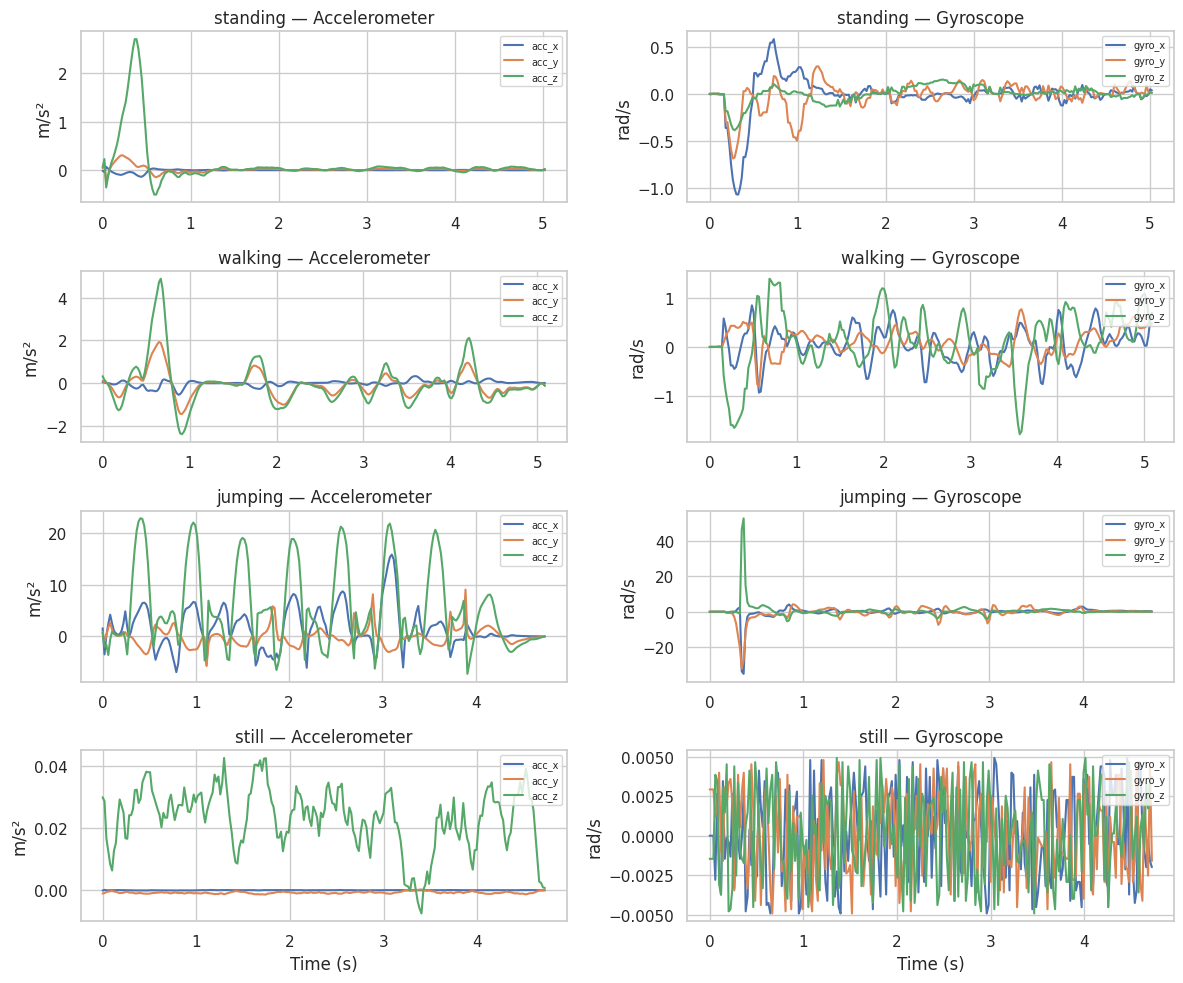

In [8]:
fig, axes = plt.subplots(len(ACTIVITIES), 2, figsize=(12, 10), sharex=False)

for i, act in enumerate(ACTIVITIES):
    sample_df = raw_data[act][0]  # first session of this activity
    t = sample_df[TIME_COL].values
    t = t - t[0]

    axes[i, 0].plot(t, sample_df["acc_x"], label="acc_x")
    axes[i, 0].plot(t, sample_df["acc_y"], label="acc_y")
    axes[i, 0].plot(t, sample_df["acc_z"], label="acc_z")
    axes[i, 0].set_title(f"{act} — Accelerometer")
    axes[i, 0].set_ylabel("m/s²")
    axes[i, 0].legend(fontsize=7, loc="upper right")

    axes[i, 1].plot(t, sample_df["gyro_x"], label="gyro_x")
    axes[i, 1].plot(t, sample_df["gyro_y"], label="gyro_y")
    axes[i, 1].plot(t, sample_df["gyro_z"], label="gyro_z")
    axes[i, 1].set_title(f"{act} — Gyroscope")
    axes[i, 1].set_ylabel("rad/s")
    axes[i, 1].legend(fontsize=7, loc="upper right")

axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig("sample_raw_data.png", dpi=150)
plt.show()


## 3. Windowing

Justify your window size based on sampling rate — e.g. at 50 Hz, a 1s window = 50 samples,
enough to capture a gait cycle for walking. Adjust `WINDOW_SEC` and `OVERLAP` below.


In [9]:
WINDOW_SEC = 1.0
OVERLAP = 0.5  # 50% overlap between consecutive windows

def make_windows(df, rate_hz, window_sec=WINDOW_SEC, overlap=OVERLAP):
    window_size = int(window_sec * rate_hz)
    step = int(window_size * (1 - overlap))
    windows = []
    for start in range(0, len(df) - window_size + 1, step):
        windows.append(df.iloc[start:start + window_size])
    return windows


## 4. Feature Extraction

Time-domain: mean, std/variance, signal magnitude area (SMA), axis correlation.
Frequency-domain: dominant frequency, spectral energy (via FFT).


In [10]:
def extract_features(window, rate_hz):
    feats = {}
    axes = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]

    for ax in axes:
        if ax not in window.columns:
            continue
        signal = window[ax].values

        # Time-domain
        feats[f"{ax}_mean"] = np.mean(signal)
        feats[f"{ax}_std"] = np.std(signal)
        feats[f"{ax}_var"] = np.var(signal)

        # Frequency-domain (per axis)
        fft_vals = np.abs(rfft(signal - np.mean(signal)))
        freqs = rfftfreq(len(signal), d=1.0 / rate_hz)
        if len(fft_vals) > 1:
            dom_idx = np.argmax(fft_vals[1:]) + 1  # skip DC component
            feats[f"{ax}_dom_freq"] = freqs[dom_idx]
            feats[f"{ax}_spectral_energy"] = np.sum(fft_vals ** 2)
        else:
            feats[f"{ax}_dom_freq"] = 0.0
            feats[f"{ax}_spectral_energy"] = 0.0

    # Signal Magnitude Area (accelerometer)
    if all(a in window.columns for a in ["acc_x", "acc_y", "acc_z"]):
        ax_, ay_, az_ = (window[a].values for a in ["acc_x", "acc_y", "acc_z"])
        feats["acc_sma"] = np.mean(np.abs(ax_) + np.abs(ay_) + np.abs(az_))
        # Axis correlation
        feats["acc_xy_corr"] = np.corrcoef(ax_, ay_)[0, 1] if np.std(ax_) > 0 and np.std(ay_) > 0 else 0
        feats["acc_xz_corr"] = np.corrcoef(ax_, az_)[0, 1] if np.std(ax_) > 0 and np.std(az_) > 0 else 0

    return feats


In [11]:
# Build feature dataset across all activities and sessions
all_rows = []
for act, dfs in raw_data.items():
    for df in dfs:
        rate = estimate_sampling_rate(df) or TARGET_RATE_HZ
        for w in make_windows(df, rate):
            f = extract_features(w, rate)
            f["activity"] = act
            f["source_file"] = df["source_file"].iloc[0]
            all_rows.append(f)

feature_df = pd.DataFrame(all_rows).dropna()
print(feature_df.shape)
feature_df.head()


(506, 35)


,acc_x_mean,acc_x_std,acc_x_var,acc_x_dom_freq,acc_x_spectral_energy,acc_y_mean,acc_y_std,acc_y_var,acc_y_dom_freq,acc_y_spectral_energy,...,gyro_z_mean,gyro_z_std,gyro_z_var,gyro_z_dom_freq,gyro_z_spectral_energy,acc_sma,acc_xy_corr,acc_xz_corr,activity,source_file
0,-0.028862,0.050130,0.002513,1.007118,3.016870,0.041764,0.131418,0.017271,1.007118,20.733356,...,-0.063457,0.138292,0.019125,1.007118,22.959109,0.849101,-0.779359,-0.801903,standing,standing_1
1,0.000416,0.015900,0.000253,4.028474,0.303494,-0.028815,0.044317,0.001964,2.014237,2.357793,...,-0.019333,0.066098,0.004369,1.007118,5.244963,0.178421,-0.754992,-0.937848,standing,standing_1
2,-0.002421,0.002374,0.000006,3.021355,0.006767,-0.000593,0.023275,0.000542,2.014237,0.650330,...,-0.048933,0.051987,0.002703,1.007118,3.244495,0.064813,0.032859,0.021814,standing,standing_1
3,-0.001318,0.001186,0.000001,2.014237,0.001690,0.009158,0.009001,0.000081,2.014237,0.097262,...,0.011536,0.062135,0.003861,1.007118,4.634768,0.036686,-0.955972,-0.955646,standing,standing_1
4,-0.000752,0.001119,0.000001,3.021355,0.001503,0.005852,0.007862,0.000062,3.021355,0.074203,...,0.090829,0.045005,0.002025,1.007118,2.431532,0.028730,-0.901377,-0.893394,standing,standing_1


## 5. Normalization

Z-score normalization on features (fit only on training data, applied to test data too).


In [12]:
feature_cols = [c for c in feature_df.columns if c not in ("activity", "source_file")]

# Train/test split by FILE (not by window!) to keep unseen files truly unseen
files_by_activity = feature_df.groupby("activity")["source_file"].unique()
test_files = []
for act, files in files_by_activity.items():
    n_test = max(1, int(0.2 * len(files)))  # ~20% of files per activity held out
    test_files.extend(np.random.choice(files, size=n_test, replace=False))

train_df = feature_df[~feature_df["source_file"].isin(test_files)].copy()
test_df = feature_df[feature_df["source_file"].isin(test_files)].copy()

scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

print(f"Train windows: {len(train_df)}, Test windows: {len(test_df)}")
print(f"Held-out test files: {test_files}")


Train windows: 401, Test windows: 105
Held-out test files: ['jumping_8', 'jumping_10', 'standing_1', 'standing_10', 'still_9', 'still_2', 'walking_10', 'walking_7']


## 6. HMM Training (Baum-Welch via hmmlearn, with Supervised Initialization)

**Why supervised initialization?** Standard unsupervised Baum-Welch starts from a
random guess and refines it via EM. With a small dataset and one activity (jumping)
having much higher variance than the others, random initialization tends to get stuck
placing multiple hidden states inside the "easy" high-variance cluster (jumping) and
none in the harder, more similar clusters (standing/walking/still) — a classic EM
local-optimum problem.

Since we *do* know the true activity label for every training window (that's how the
data was collected), we compute an informed starting point directly from the labeled
data — mean/variance per activity, and empirical transition patterns — then let
`hmmlearn`'s Baum-Welch (EM) refine from there. This still fully satisfies "train and
optimize parameters via Baum-Welch" — we are just giving the optimizer a sensible
starting point instead of a random one, which is standard practice when labels are
available during training.

`hmmlearn` uses a convergence check on log-likelihood (`tol`) rather than a fixed
iteration count, satisfying the rubric's robust-stopping-criterion requirement.


In [13]:
activity_to_state = {act: i for i, act in enumerate(ACTIVITIES)}
state_to_activity = {i: act for act, i in activity_to_state.items()}
n_states = len(ACTIVITIES)

X_train = train_df[feature_cols].values
lengths = train_df.groupby("source_file", sort=False).size().values

# --- Supervised initialization ---
# 1. Initial state distribution: proportion of training FILES starting in each activity
file_labels = train_df.groupby("source_file", sort=False)["activity"].first()
init_pi = np.array([
    (file_labels == act).sum() / len(file_labels) for act in ACTIVITIES
])
init_pi = np.clip(init_pi, 1e-3, None)
init_pi /= init_pi.sum()

# 2. Transition matrix: since each recording session is a single continuous activity,
#    within-session transitions are self-transitions. We build a high-diagonal matrix
#    reflecting this persistence, with a small uniform floor on off-diagonal entries
#    so the model isn't overconfident about never switching activities.
init_A = np.full((n_states, n_states), 0.02 / (n_states - 1))
np.fill_diagonal(init_A, 0.98)

# 3. Emission parameters: per-activity mean and variance from TRAINING data only
init_means = np.zeros((n_states, len(feature_cols)))
init_covars = np.zeros((n_states, len(feature_cols)))
for act in ACTIVITIES:
    idx = activity_to_state[act]
    subset = train_df[train_df["activity"] == act][feature_cols].values
    init_means[idx] = subset.mean(axis=0)
    init_covars[idx] = subset.var(axis=0) + 1e-3  # regularize to avoid zero-variance states

model = GaussianHMM(
    n_components=n_states,
    covariance_type="diag",
    n_iter=200,
    tol=1e-4,
    init_params="",   # don't let hmmlearn randomly initialize anything
    params="stmc",    # still update startprob, transmat, means, covars during fit (Baum-Welch)
    random_state=42,
)
model.startprob_ = init_pi
model.transmat_ = init_A
model.means_ = init_means
model.covars_ = init_covars

model.fit(X_train, lengths)

print("Converged:", model.monitor_.converged)
print("Final log-likelihood:", model.monitor_.history[-1])


Converged: True
Final log-likelihood: 11759.043118707597


**Verifying state alignment:** because we initialized state `i` to correspond to
`ACTIVITIES[i]`, the learned states should stay aligned to those activities after
Baum-Welch refinement (EM moves parameters incrementally from a good starting point,
it doesn't reshuffle state identities). We confirm this below with a majority-vote
sanity check, same as before.


In [14]:
train_df["hmm_state"] = model.predict(X_train, lengths)

# Sanity check: confirm each state still majority-aligns with its intended activity
state_activity_map = {}
for state in range(n_states):
    subset = train_df[train_df["hmm_state"] == state]["activity"]
    state_activity_map[state] = subset.mode()[0] if len(subset) > 0 else ACTIVITIES[state]

print(state_activity_map)
print("Expected:", activity_to_state)


{0: 'standing', 1: 'walking', 2: 'jumping', 3: 'still'}
Expected: {'standing': 0, 'walking': 1, 'jumping': 2, 'still': 3}


## 7. Viterbi Algorithm — Implemented from Scratch

This cross-checks `hmmlearn`'s built-in decoder and demonstrates understanding of
the algorithm itself.


In [15]:
def viterbi(obs_log_prob, log_A, log_pi):
    """
    obs_log_prob: (T, n_states) log emission probabilities per timestep
    log_A: (n_states, n_states) log transition matrix
    log_pi: (n_states,) log initial state probabilities
    Returns: best_path (T,) array of state indices
    """
    T, n_states = obs_log_prob.shape
    delta = np.zeros((T, n_states))
    psi = np.zeros((T, n_states), dtype=int)

    delta[0] = log_pi + obs_log_prob[0]

    for t in range(1, T):
        for j in range(n_states):
            scores = delta[t - 1] + log_A[:, j]
            psi[t, j] = np.argmax(scores)
            delta[t, j] = np.max(scores) + obs_log_prob[t, j]

    path = np.zeros(T, dtype=int)
    path[-1] = np.argmax(delta[-1])
    for t in range(T - 2, -1, -1):
        path[t] = psi[t + 1, path[t + 1]]

    return path

def compute_log_emission(model, X):
    """Get log emission probabilities per state for each observation, using the trained GaussianHMM."""
    return model._compute_log_likelihood(X)

# Example: decode the first test file
first_test_file = test_files[0]
seq = test_df[test_df["source_file"] == first_test_file]
X_seq = seq[feature_cols].values

log_emission = compute_log_emission(model, X_seq)
log_A = np.log(model.transmat_ + 1e-12)
log_pi = np.log(model.startprob_ + 1e-12)

my_path = viterbi(log_emission, log_A, log_pi)
hmmlearn_path = model.predict(X_seq)

print("My Viterbi:     ", my_path)
print("hmmlearn decode:", hmmlearn_path)
print("Match:", np.array_equal(my_path, hmmlearn_path))


My Viterbi:      [2 2 2 2 2 2 2 2 2 2 2]
hmmlearn decode: [2 2 2 2 2 2 2 2 2 2 2]
Match: True


## 8. Visualizations


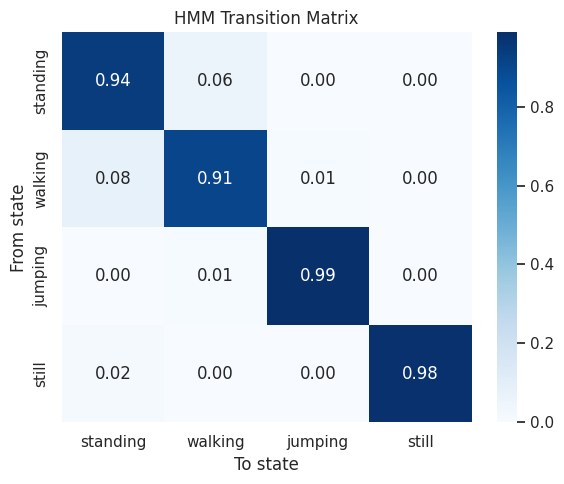

In [16]:
# Transition matrix heatmap
plt.figure(figsize=(6, 5))
labels = [state_activity_map[i] for i in range(len(ACTIVITIES))]
sns.heatmap(model.transmat_, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("HMM Transition Matrix")
plt.xlabel("To state")
plt.ylabel("From state")
plt.tight_layout()
plt.savefig("transition_matrix.png", dpi=150)
plt.show()


## 8b. Emission Parameter Visualization

The transition matrix above shows how the model believes activities follow one
another in time. Equally important is the **emission model** — what each hidden
state "expects" to observe. Since each state is a Gaussian over the 33 features,
we visualize the learned mean feature profile per state as a heatmap. Distinct
row patterns confirm the states have learned genuinely different signal profiles,
not just different transition behavior.


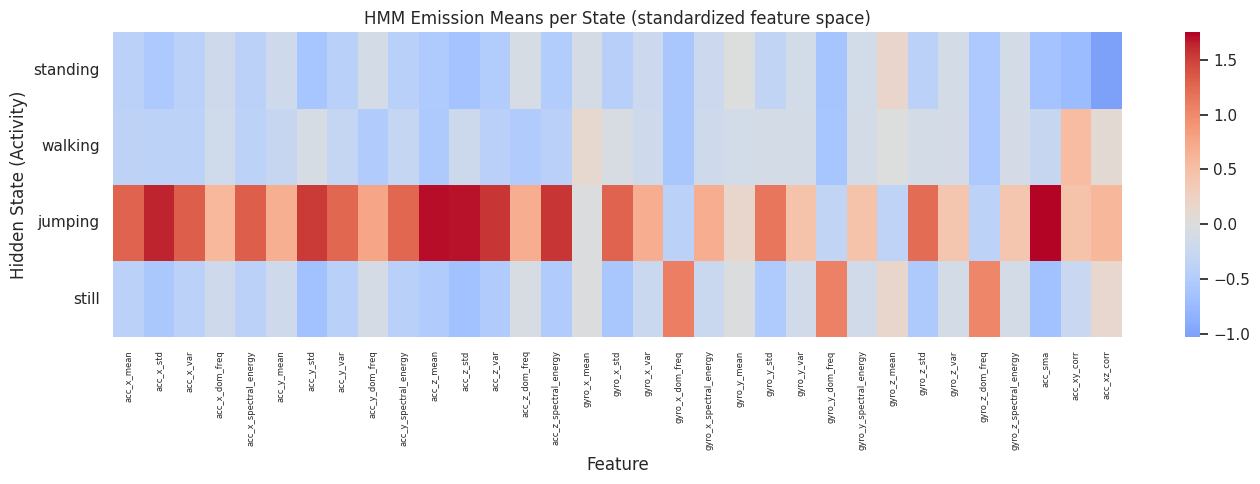

In [17]:
# Emission means heatmap: which features characterize each hidden state
means_df = pd.DataFrame(model.means_, index=labels, columns=feature_cols)

plt.figure(figsize=(14, 5))
ax = sns.heatmap(means_df, cmap="coolwarm", center=0, xticklabels=True, yticklabels=True)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
plt.title("HMM Emission Means per State (standardized feature space)")
plt.xlabel("Feature")
plt.ylabel("Hidden State (Activity)")
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig("emission_means.png", dpi=150)
plt.show()


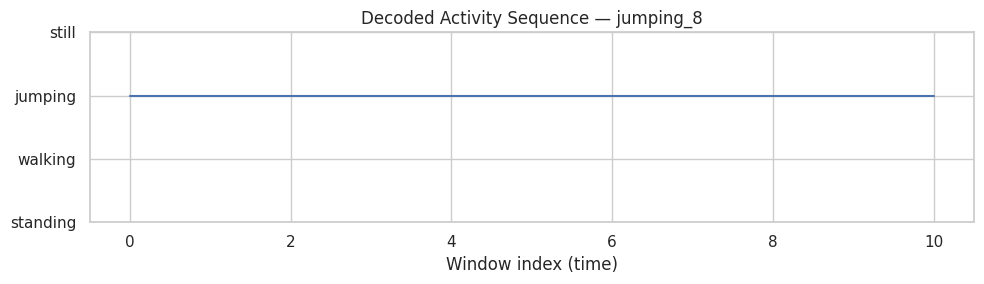

In [18]:
# Decoded sequence plot for one test file
plt.figure(figsize=(10, 3))
plt.step(range(len(my_path)), my_path, where="mid")
plt.yticks(range(len(ACTIVITIES)), [state_activity_map[i] for i in range(len(ACTIVITIES))])
plt.xlabel("Window index (time)")
plt.title(f"Decoded Activity Sequence — {first_test_file}")
plt.tight_layout()
plt.savefig("decoded_sequence.png", dpi=150)
plt.show()


## 9. Evaluation on Unseen Data

Sensitivity, specificity, accuracy per activity, plus confusion matrix.


Overall accuracy: 0.905


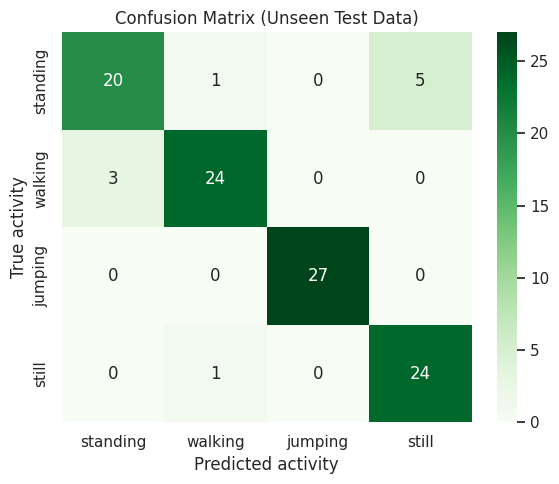

In [19]:
X_test = test_df[feature_cols].values
test_lengths = test_df.groupby("source_file").size().values

predicted_states = model.predict(X_test, test_lengths)
predicted_activities = [state_activity_map[s] for s in predicted_states]
true_activities = test_df["activity"].values

overall_acc = accuracy_score(true_activities, predicted_activities)
print(f"Overall accuracy: {overall_acc:.3f}")

cm = confusion_matrix(true_activities, predicted_activities, labels=ACTIVITIES)
cm_df = pd.DataFrame(cm, index=ACTIVITIES, columns=ACTIVITIES)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix (Unseen Test Data)")
plt.ylabel("True activity")
plt.xlabel("Predicted activity")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


In [20]:
# Per-activity sensitivity & specificity
results = []
for i, act in enumerate(ACTIVITIES):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan
    n_samples = cm[i, :].sum()

    results.append({
        "Activity": act,
        "Samples": n_samples,
        "Sensitivity": round(sensitivity, 3),
        "Specificity": round(specificity, 3),
        "Overall Accuracy": round(overall_acc, 3),
    })

results_table = pd.DataFrame(results)
results_table


,Activity,Samples,Sensitivity,Specificity,Overall Accuracy
0,standing,26,0.769,0.962,0.905
1,walking,27,0.889,0.974,0.905
2,jumping,27,1.000,1.000,0.905
3,still,25,0.960,0.938,0.905
